In [9]:
from resources.archive.cut_off_black_segments import cut_off_black_segments
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from resources.find_x import find

In [10]:
PROJECT_DIR = Path(r"C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons")
NIFTI_DIR = PROJECT_DIR / "data" / "niftis"
FILE_NAME = "08liuqdn.nii.gz"
FILE_PATH = NIFTI_DIR / FILE_NAME
LABELS_PATH = PROJECT_DIR / "data" / "niftis" / "train_labels_JNDlMjr.csv"
labels = pd.read_csv(LABELS_PATH)

In [3]:
def find_valley_between_two_peaks(values, min_peak_distance=5):
    values = np.asarray(values)

    first_peak = int(np.argmax(values))

    left_part = values[:max(0, first_peak - min_peak_distance)]
    right_part = values[min(len(values), first_peak + min_peak_distance):]

    candidates = []

    if len(left_part) > 0:
        left_peak = int(np.argmax(left_part))
        candidates.append(left_peak)

    if len(right_part) > 0:
        right_peak = int(np.argmax(right_part)) + first_peak + min_peak_distance
        candidates.append(right_peak)

    if not candidates:
        return first_peak, first_peak, first_peak

    second_peak = max(candidates, key=lambda idx: values[idx])

    peak_left = min(first_peak, second_peak)
    peak_right = max(first_peak, second_peak)

    valley_x = peak_left + int(np.argmin(values[peak_left:peak_right + 1]))

    return first_peak, second_peak, valley_x


1/20: 01nouhtc.nii.gz
UID: 01nouhtc
Label: 0.0 -> Not pathological
Najlepsze best_x: 64
Środkowa płaszczyzna middle_x: 65


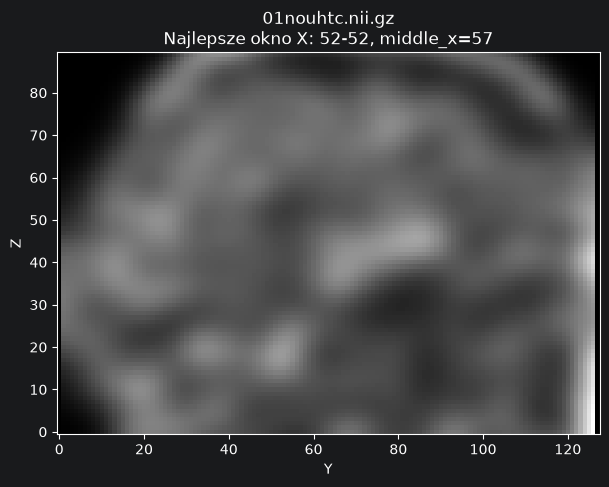

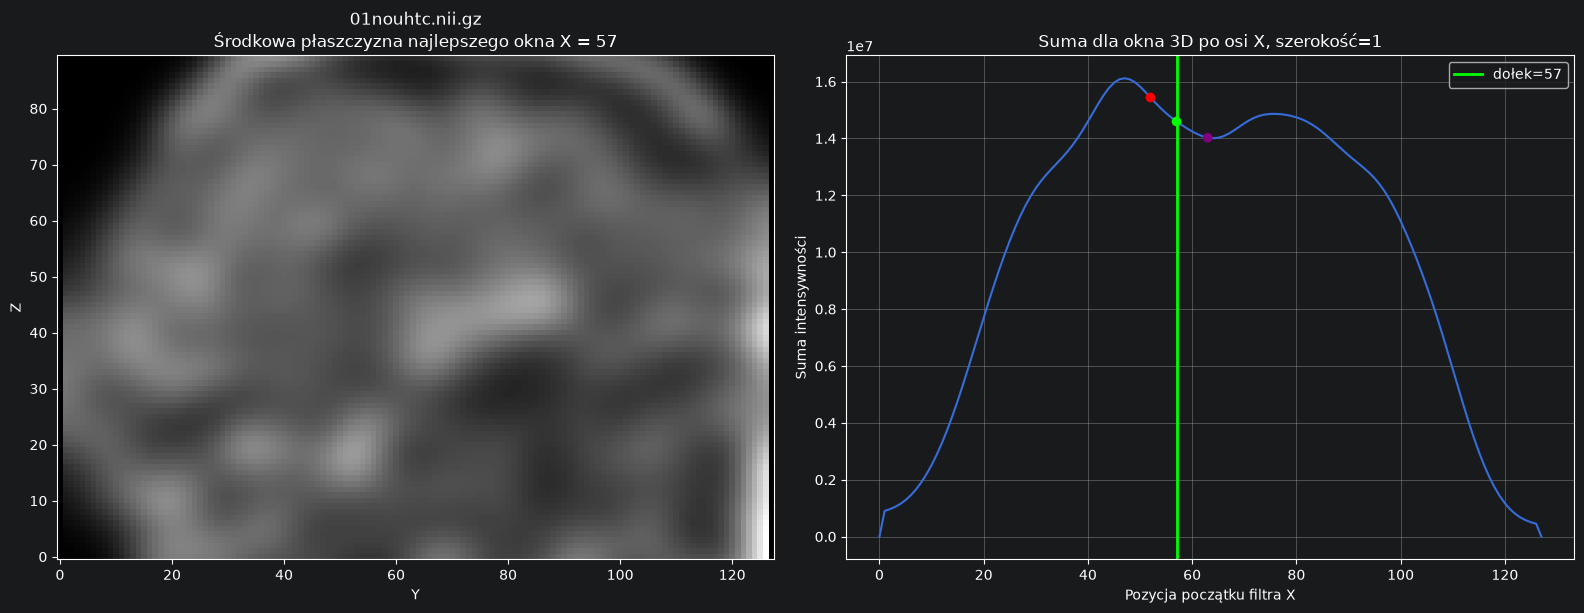


2/20: 0224wk0y.nii.gz
UID: 0224wk0y
Label: 1.0 -> Pathological
Najlepsze best_x: 51
Środkowa płaszczyzna middle_x: 51


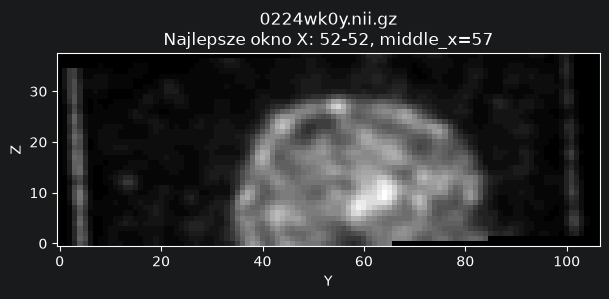

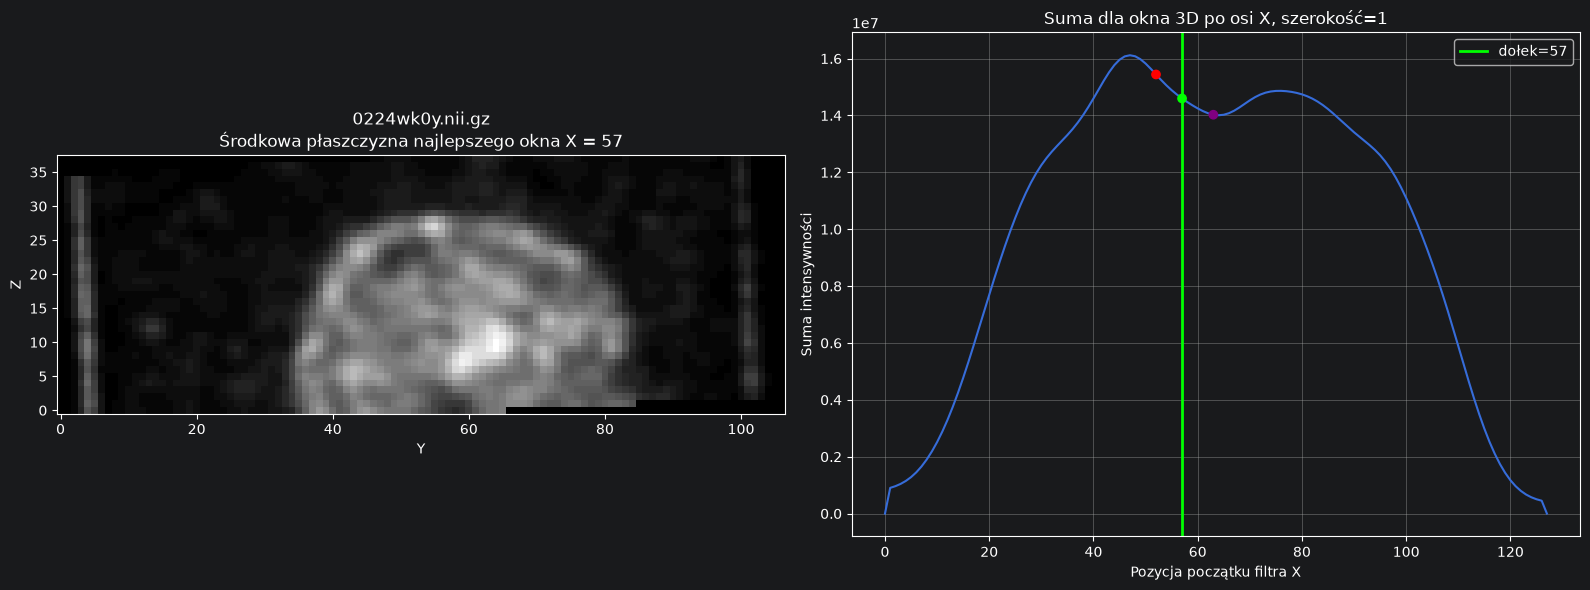


3/20: 049enulq.nii.gz
UID: 049enulq
Label: 0.0 -> Not pathological
Najlepsze best_x: 65
Środkowa płaszczyzna middle_x: 65


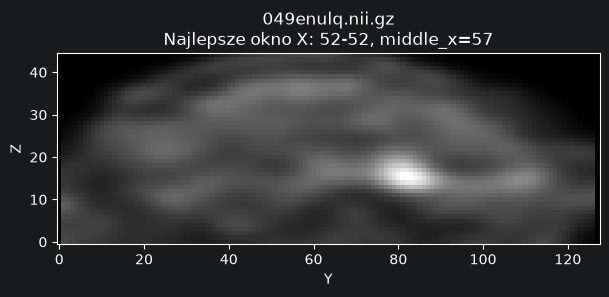

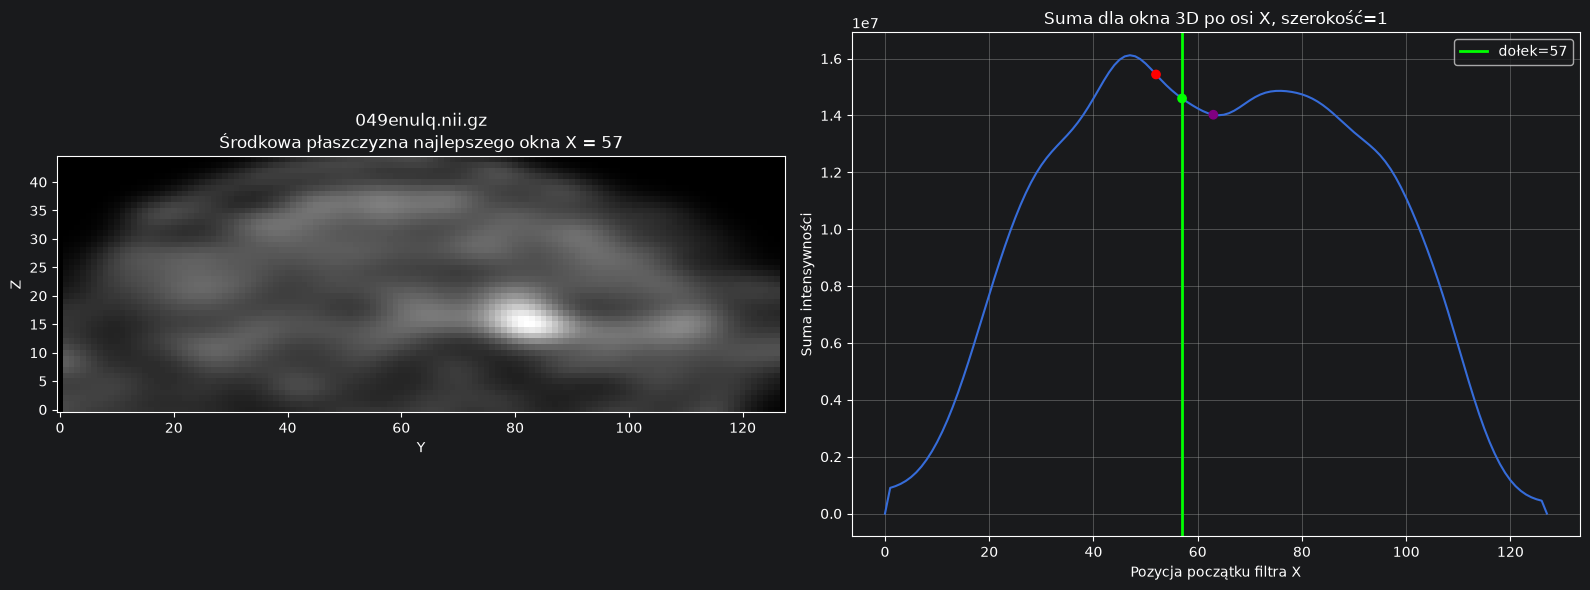


4/20: 04x0qzfh.nii.gz
UID: 04x0qzfh
Label: 0.0 -> Not pathological
Najlepsze best_x: 60
Środkowa płaszczyzna middle_x: 61


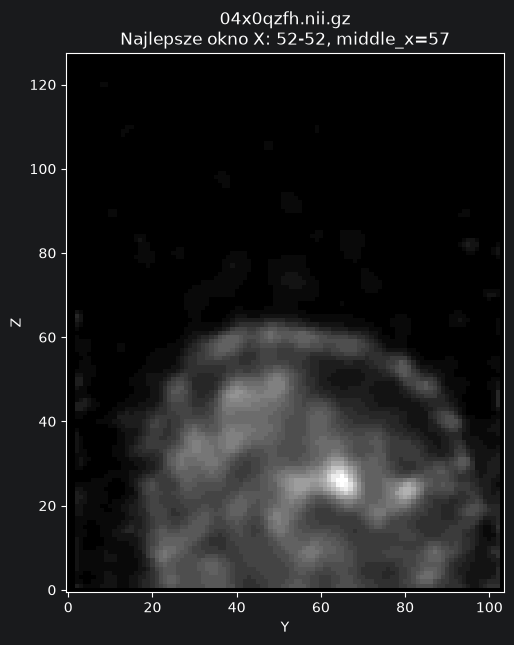

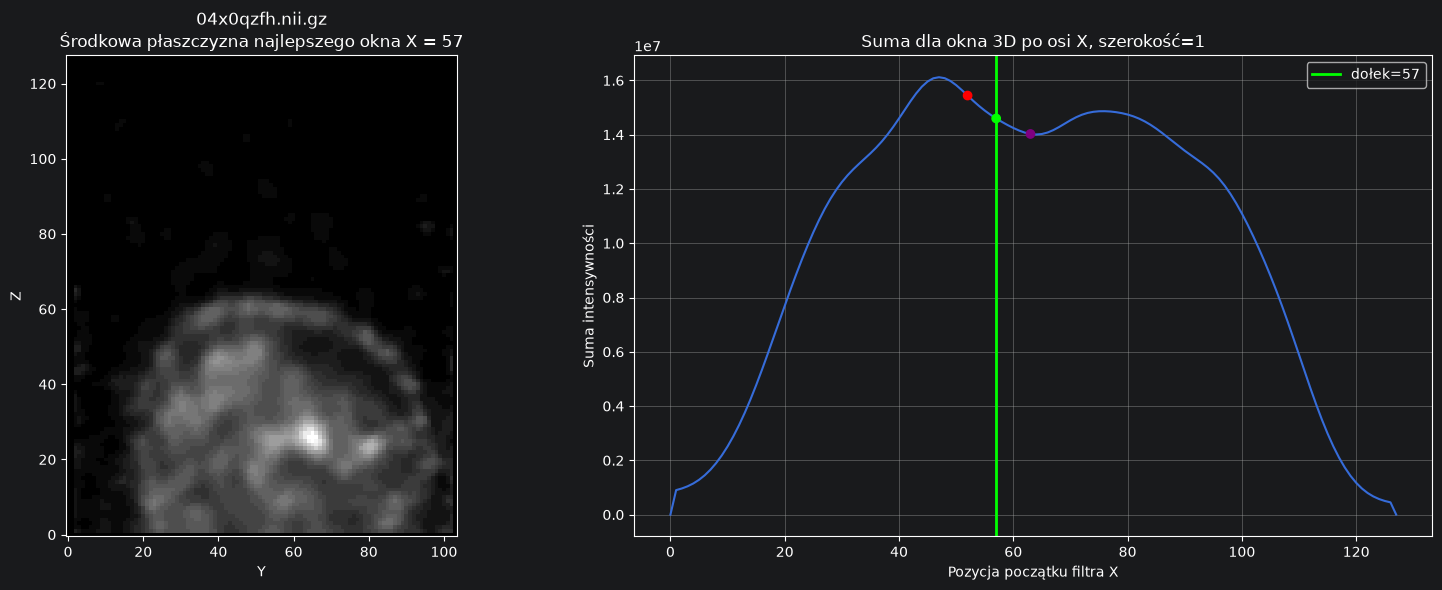


5/20: 05xt54fn.nii.gz
UID: 05xt54fn
Label: 0.0 -> Not pathological
Najlepsze best_x: 56
Środkowa płaszczyzna middle_x: 56


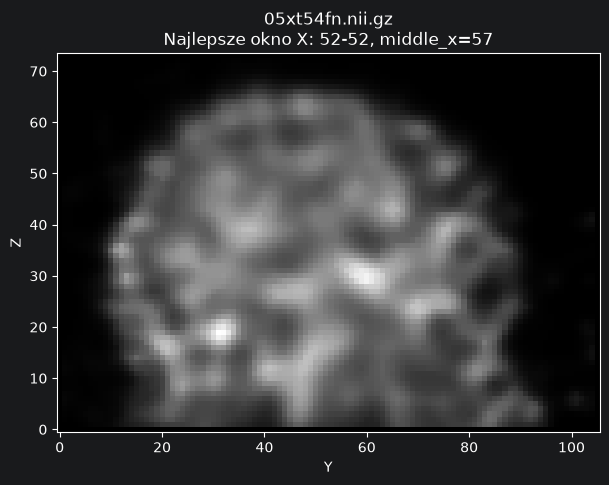

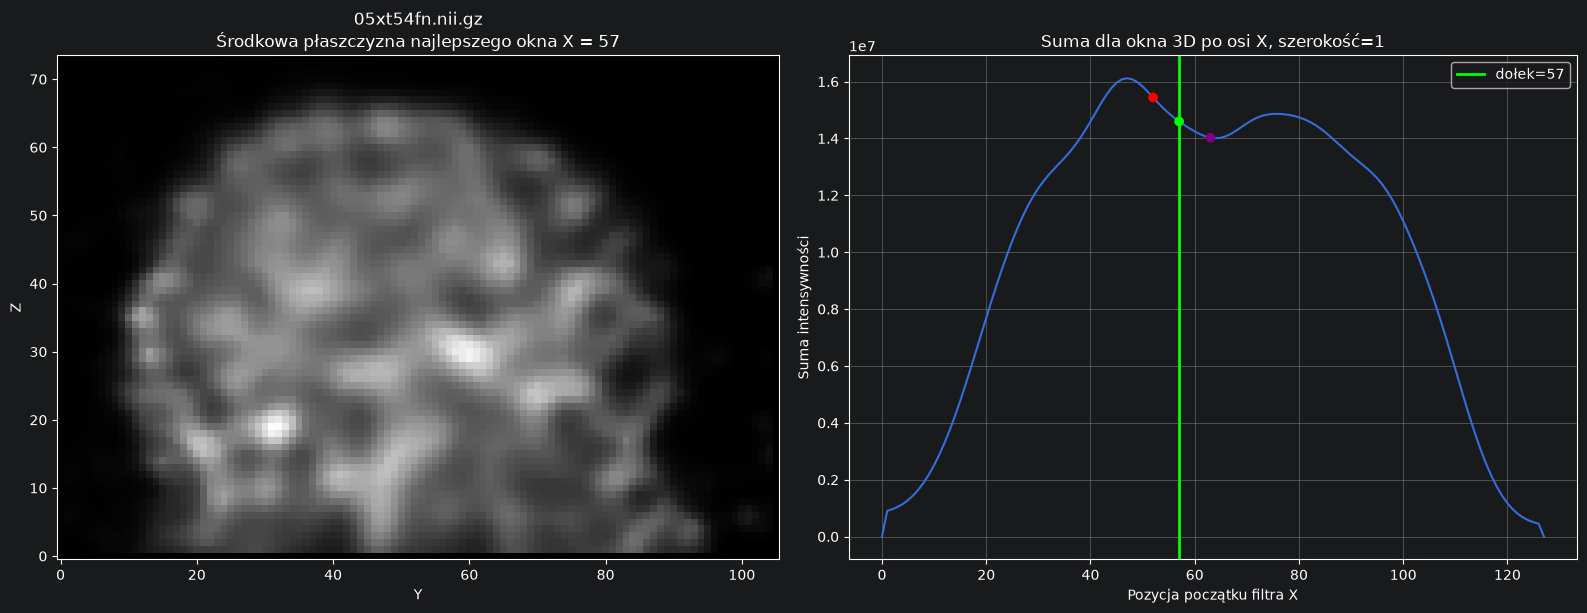


6/20: 06akt7zq.nii.gz
UID: 06akt7zq
Label: 1.0 -> Pathological
Najlepsze best_x: 55
Środkowa płaszczyzna middle_x: 55


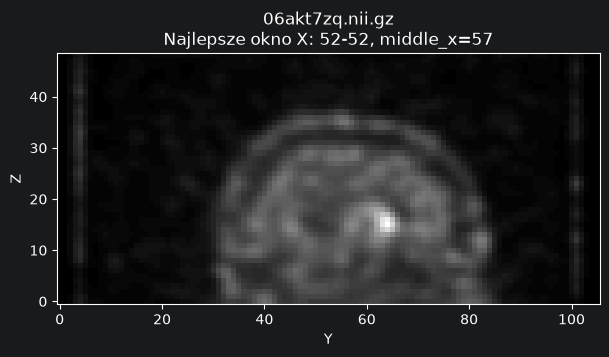

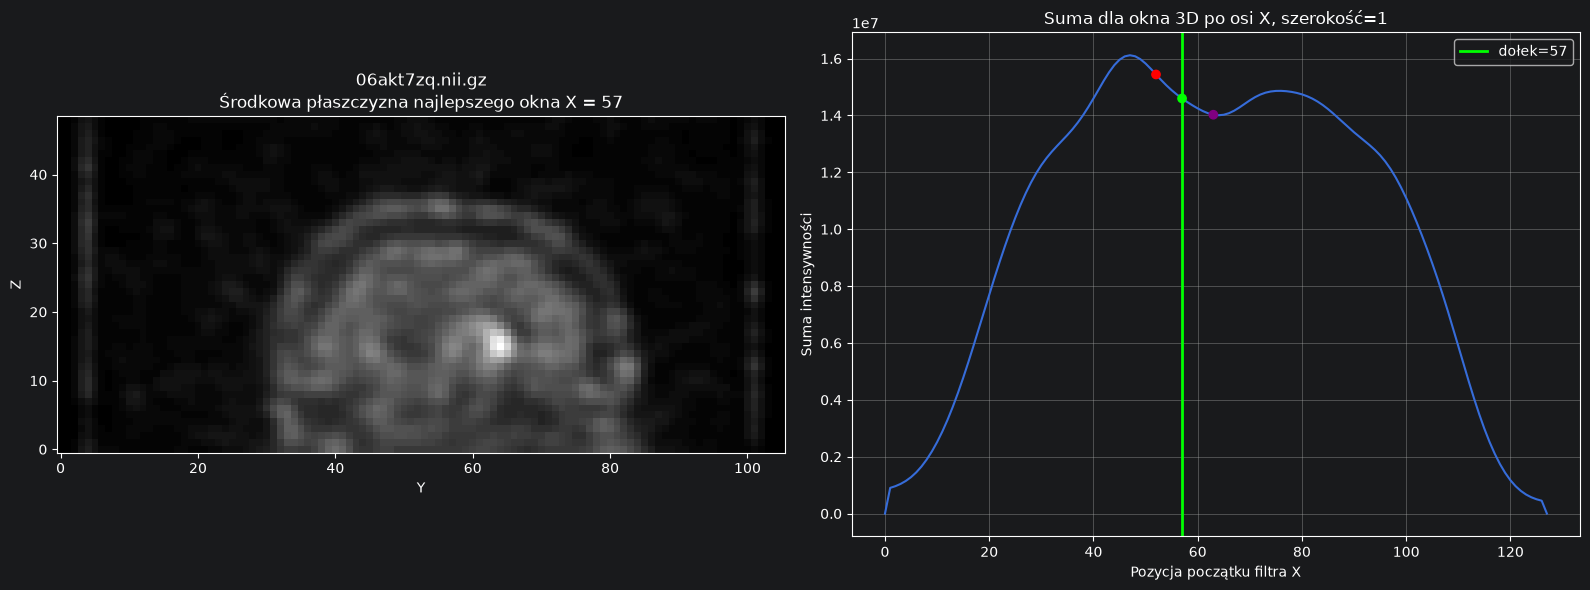


7/20: 06nkwfg3.nii.gz
UID: 06nkwfg3
Label: 0.0 -> Not pathological
Najlepsze best_x: 62
Środkowa płaszczyzna middle_x: 62


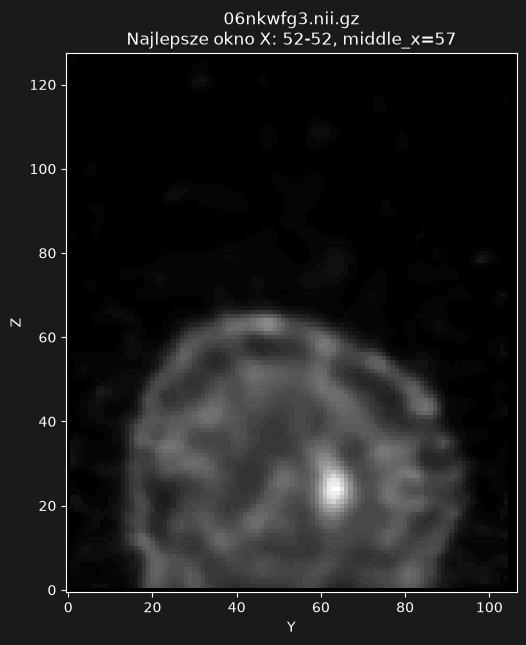

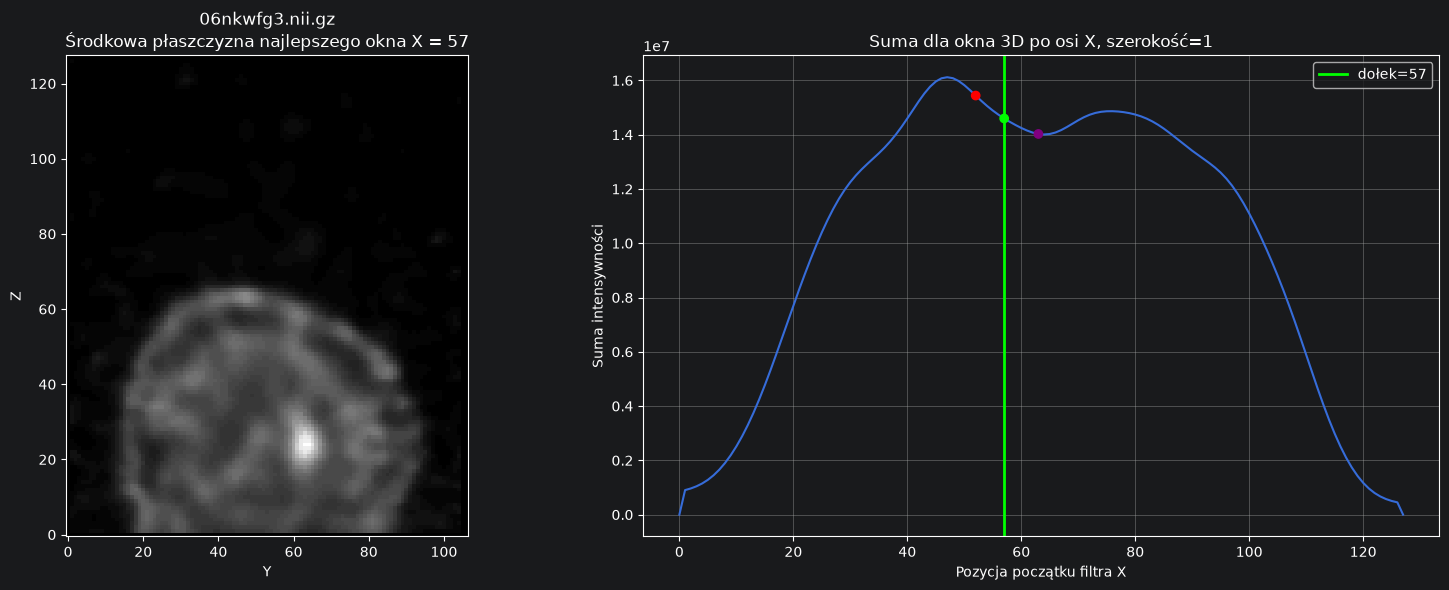


8/20: 07gbasf5.nii.gz
UID: 07gbasf5
Label: 0.0 -> Not pathological
Najlepsze best_x: 42
Środkowa płaszczyzna middle_x: 43


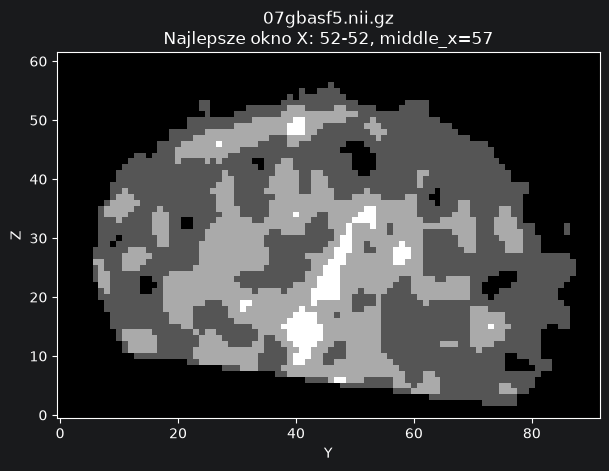

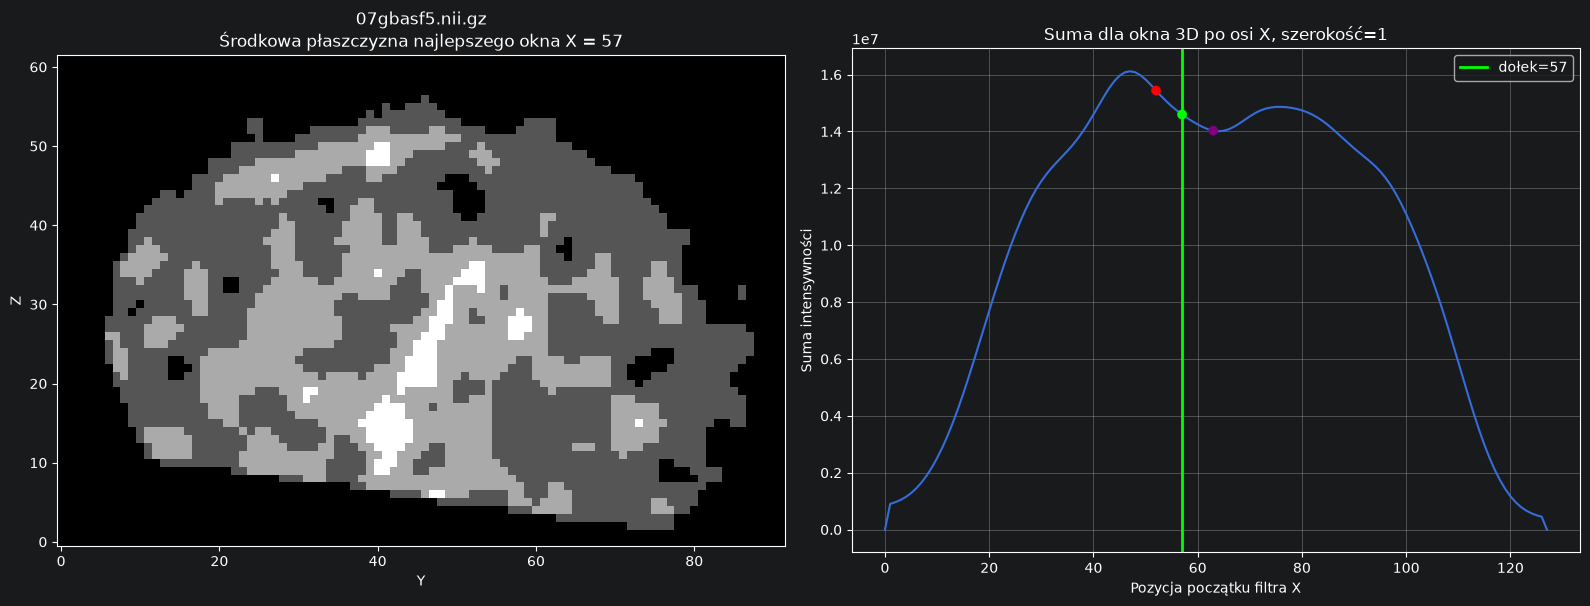


9/20: 07s387j5.nii.gz
UID: 07s387j5
Label: 0.0 -> Not pathological
Najlepsze best_x: 50
Środkowa płaszczyzna middle_x: 50


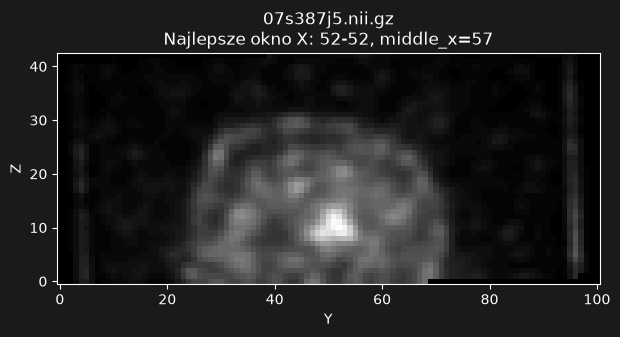

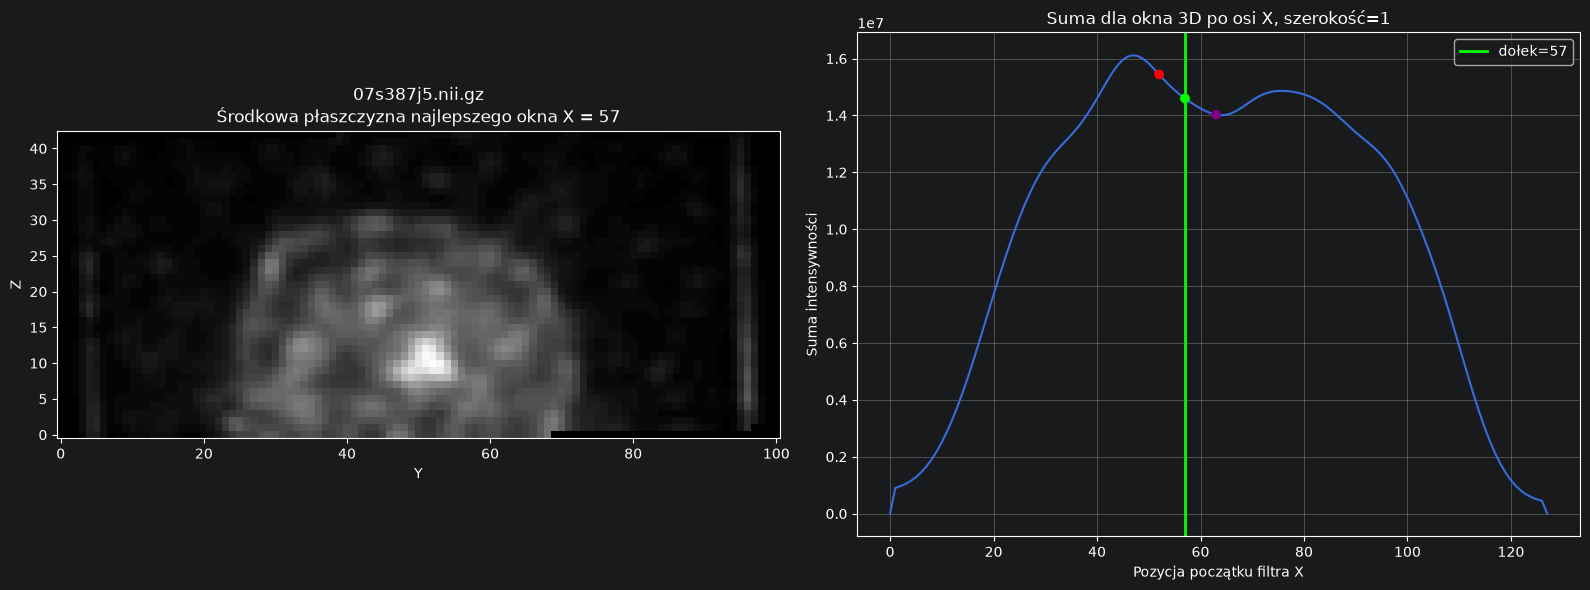


10/20: 085rntdr.nii.gz
UID: 085rntdr
Label: 1.0 -> Pathological
Najlepsze best_x: 55
Środkowa płaszczyzna middle_x: 54


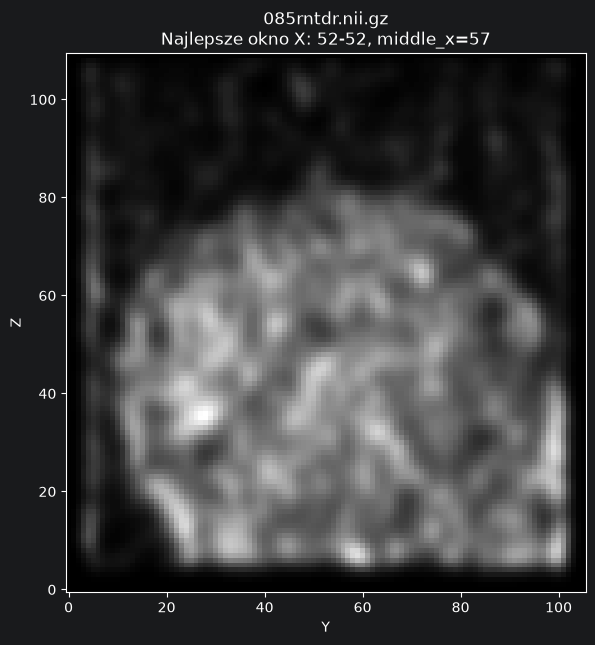

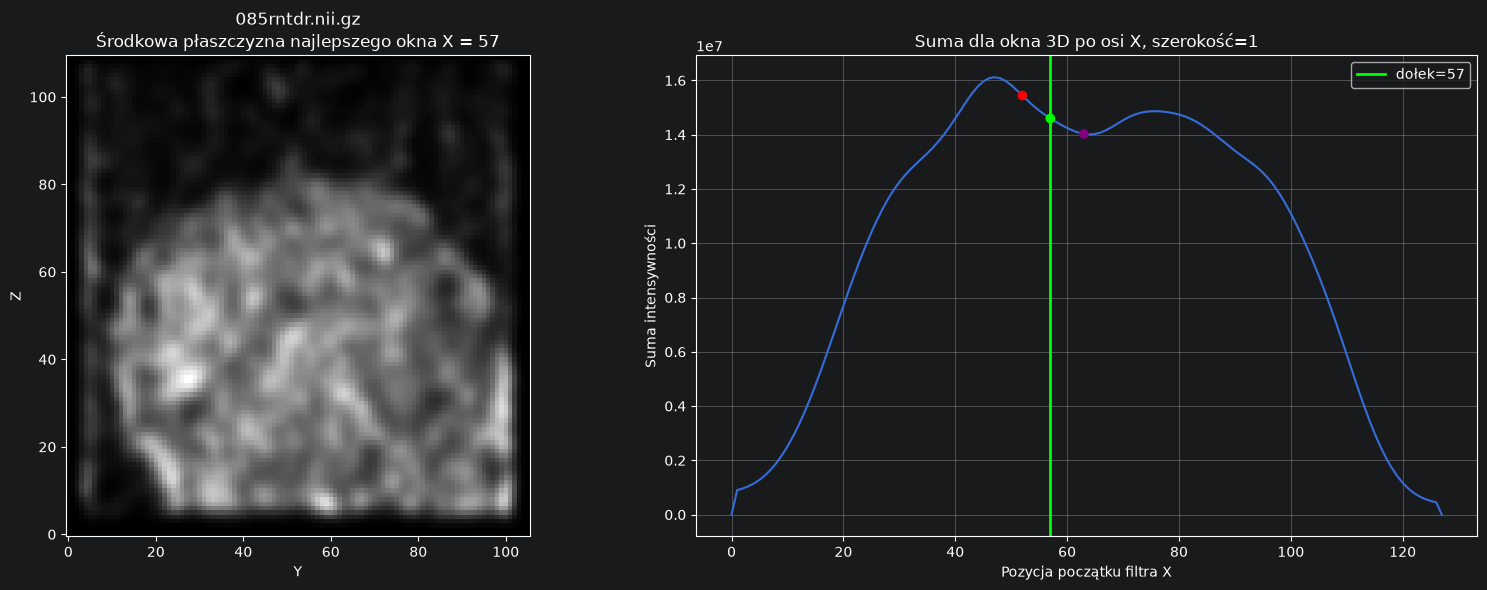


11/20: 08liuqdn.nii.gz
UID: 08liuqdn
Label: 1.0 -> Pathological
Najlepsze best_x: 63
Środkowa płaszczyzna middle_x: 64


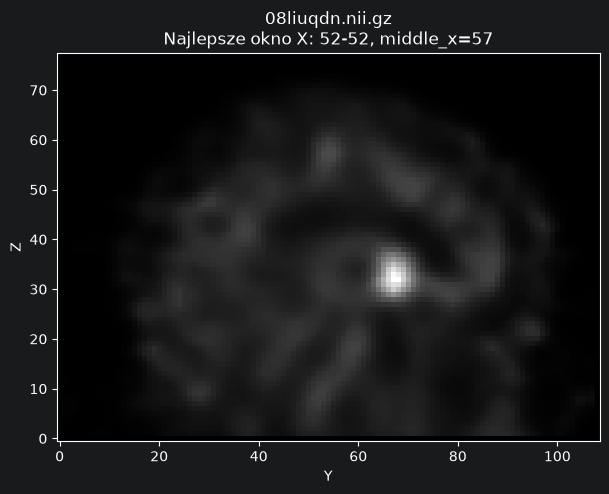

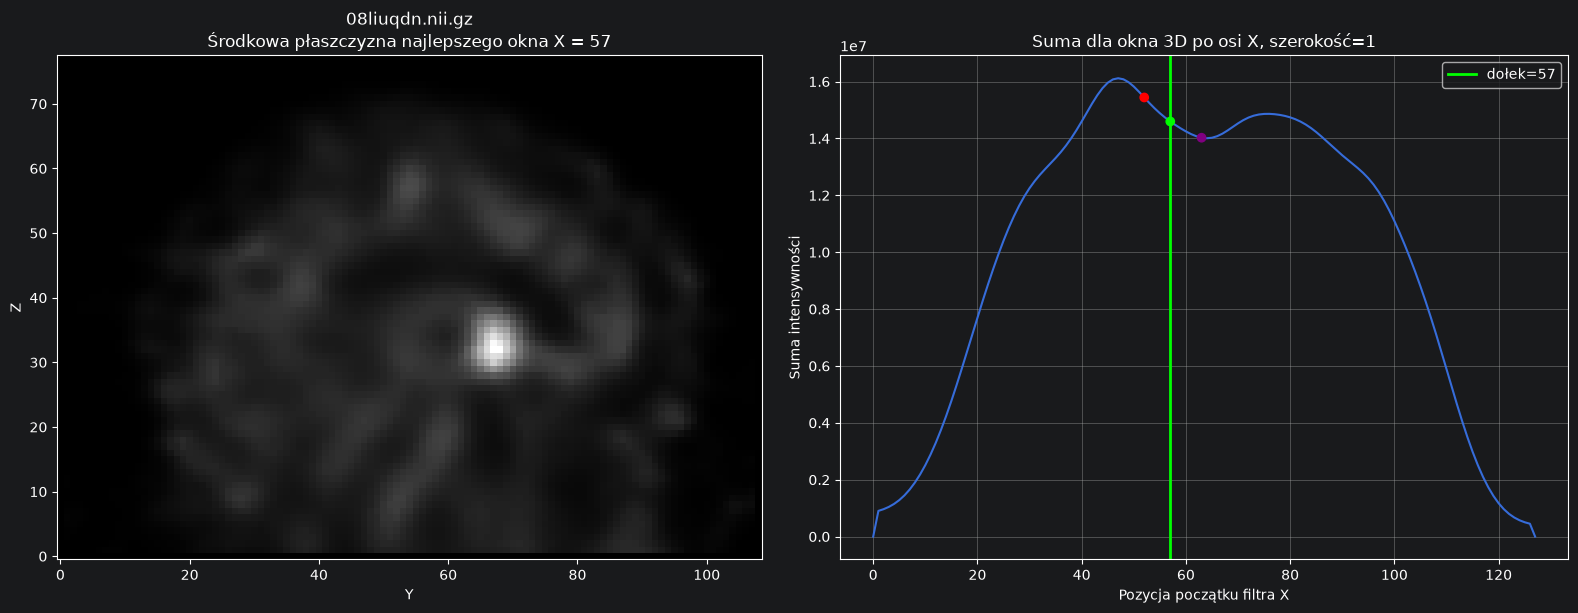


12/20: 08uhbxlb.nii.gz
UID: 08uhbxlb
Label: 1.0 -> Pathological
Najlepsze best_x: 48
Środkowa płaszczyzna middle_x: 49


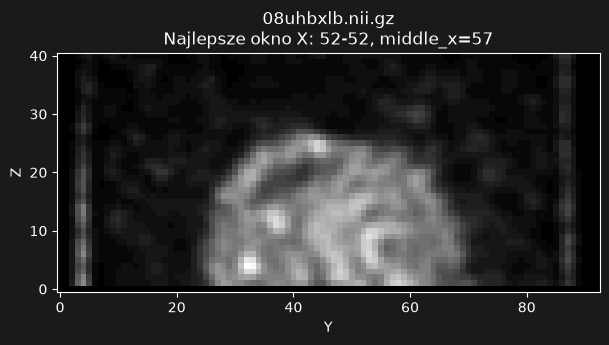

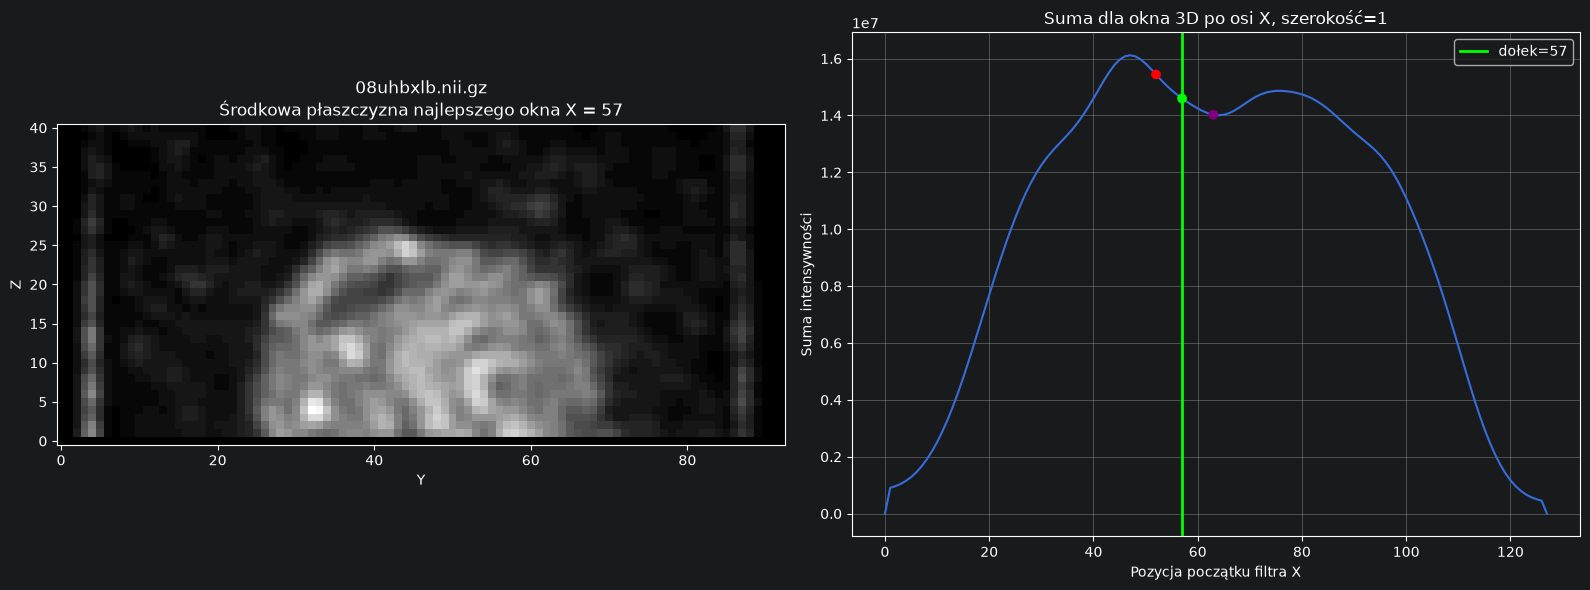


13/20: 09lzrk79.nii.gz
UID: 09lzrk79
Label: 0.0 -> Not pathological
Najlepsze best_x: 54
Środkowa płaszczyzna middle_x: 64


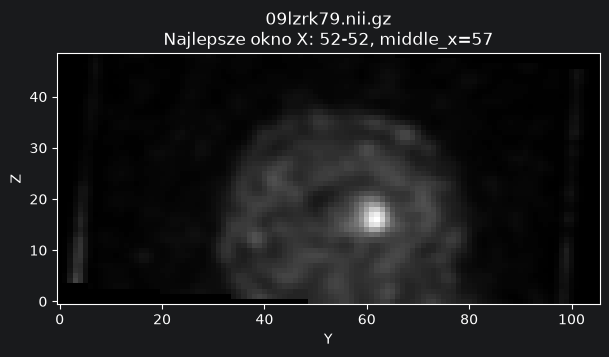

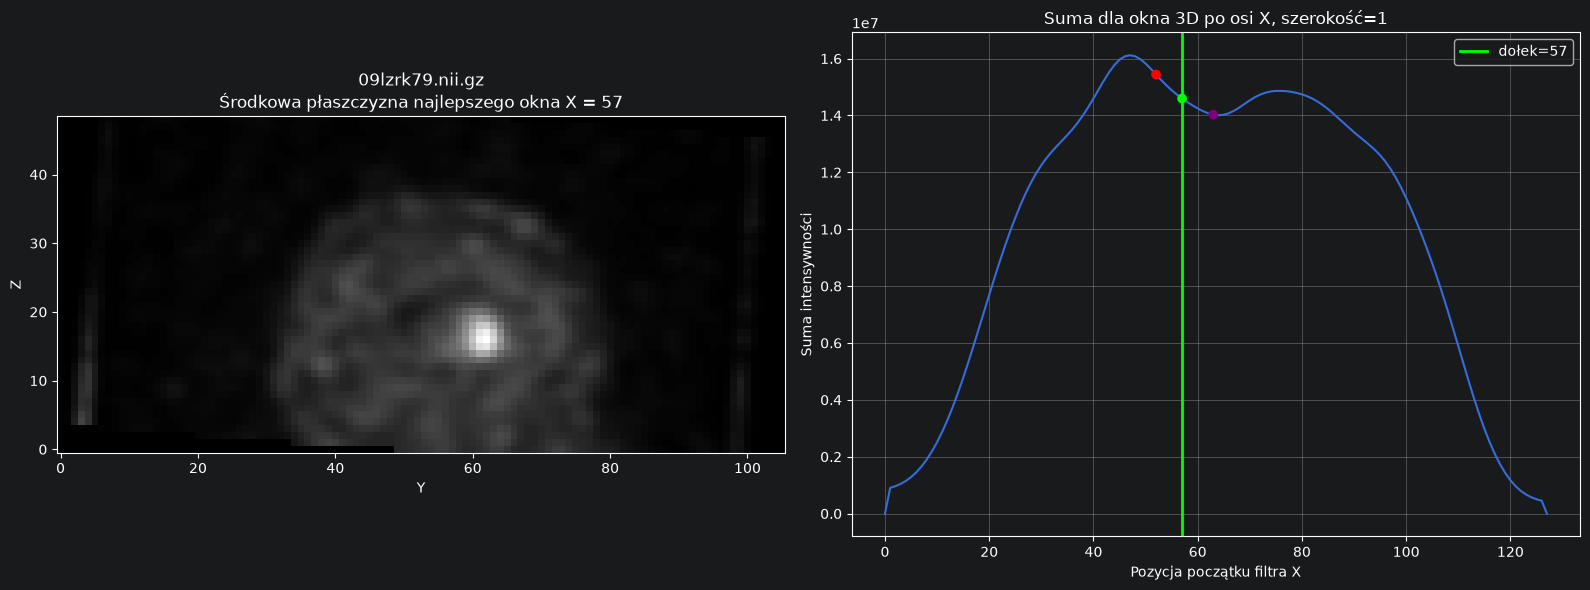


14/20: 09vs9kkh.nii.gz
UID: 09vs9kkh
Label: 1.0 -> Pathological
Najlepsze best_x: 63
Środkowa płaszczyzna middle_x: 61


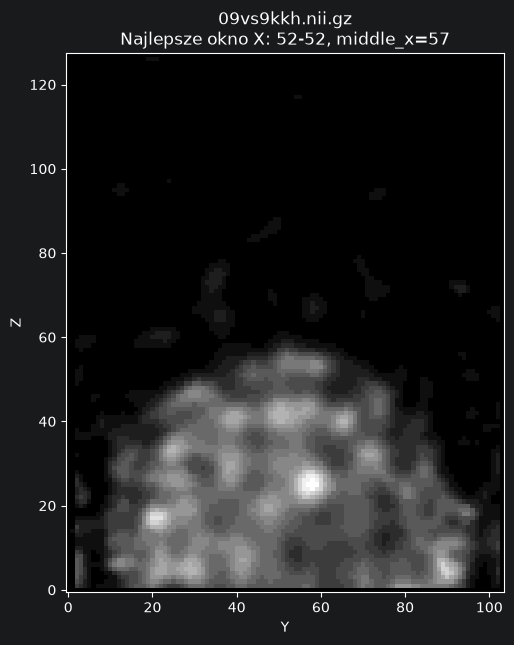

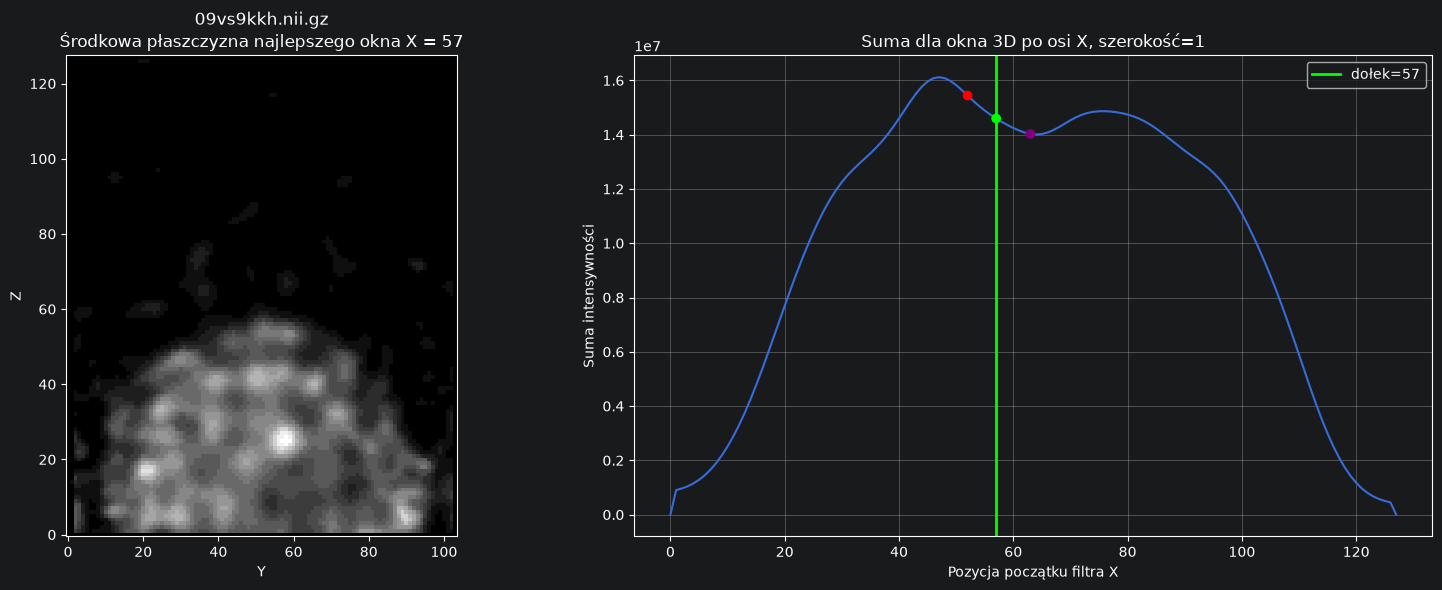


15/20: 0aeoorbt.nii.gz
UID: 0aeoorbt
Label: 1.0 -> Pathological
Najlepsze best_x: 62
Środkowa płaszczyzna middle_x: 73


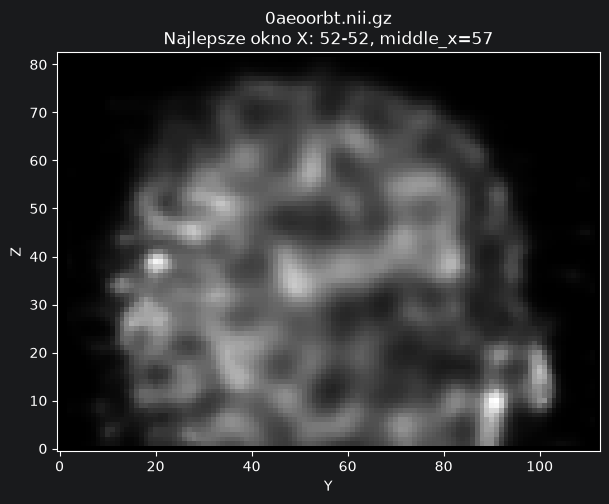

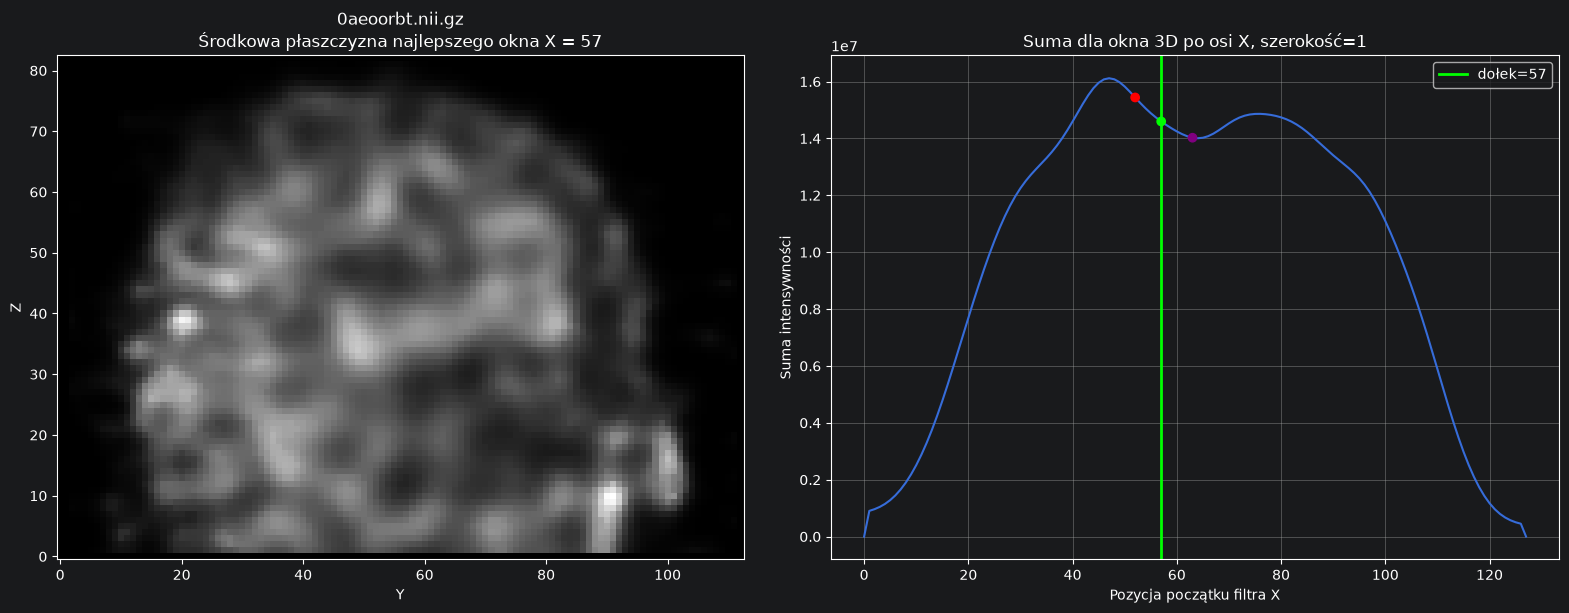


16/20: 0bq1s9ry.nii.gz
UID: 0bq1s9ry
Label: 1.0 -> Pathological
Najlepsze best_x: 59
Środkowa płaszczyzna middle_x: 59


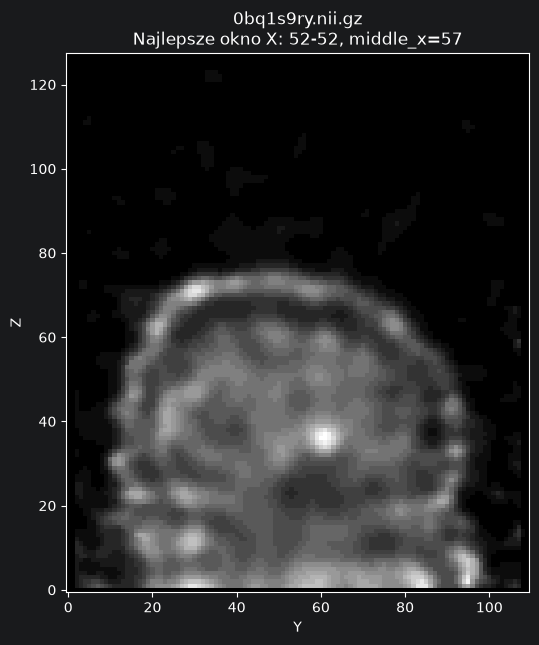

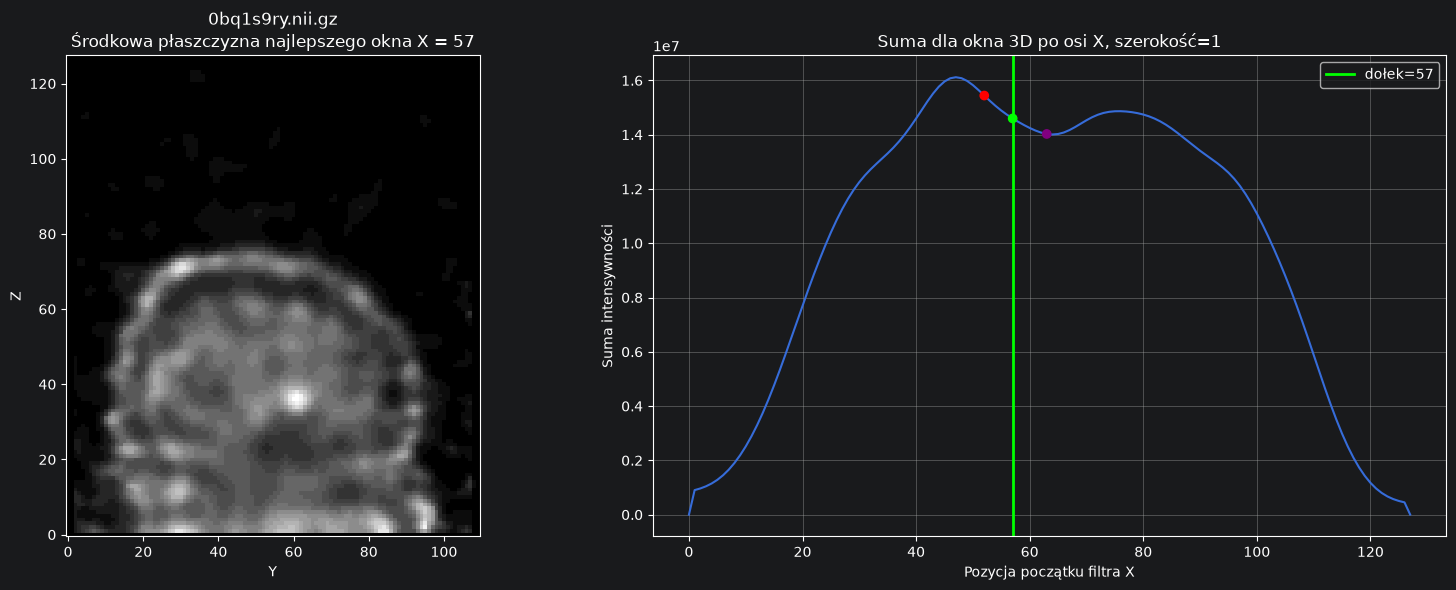


17/20: 0dk0get8.nii.gz
UID: 0dk0get8
Label: 0.0 -> Not pathological
Najlepsze best_x: 25
Środkowa płaszczyzna middle_x: 21


IndexError: index 57 is out of bounds for axis 0 with size 48

<Figure size 700x700 with 0 Axes>

In [12]:
files = sorted(NIFTI_DIR.glob("*.nii.gz"))

filter_width = 1
n_images = 20
target_map = labels.set_index("uid")["is_pathologic"].to_dict()

for i, file_path in enumerate(files[:n_images]):
    uid = file_path.name.replace(".nii.gz", "")
    target = target_map[uid]
    diagnosis = "Pathological" if target == 1 else "Not pathological"

    print(f"\n{i + 1}/{n_images}: {file_path.name}")
    print(f"UID: {uid}")
    print(f"Label: {target} -> {diagnosis}")
    cropped, _ = cut_off_black_segments(
        path=file_path,
        threshold=0,
        margin=1,
    )

    x_max, y_max, z_max = cropped.shape

    filter_sum_3d_x = np.zeros(x_max - filter_width + 1)

    for x_pos in range(x_max - filter_width + 1):
        area = cropped[x_pos:x_pos + filter_width, :, :]
        filter_sum_3d_x[x_pos] = np.sum(area)

    peak_1_x, peak_2_x, valley_x = find_valley_between_two_peaks(
        filter_sum_3d_x,
        min_peak_distance=5
    )

    best_x = peak_1_x
    middle_x = valley_x

    print("Shape po crop:", cropped.shape)
    print("Najlepsze best_x:", best_x)
    print("Środkowa płaszczyzna middle_x:", middle_x)
    print("Maksymalna suma:", filter_sum_3d_x[best_x])

    plt.figure(figsize=(7, 7))
    plt.imshow(cropped[middle_x, :, :].T, cmap="gray", origin="lower")
    plt.title(
        f"{file_path.name}\n"
        f"Najlepsze okno X: {best_x}-{best_x + filter_width - 1}, "
        f"middle_x={middle_x}"
    )
    plt.xlabel("Y")
    plt.ylabel("Z")
    plt.show()
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].imshow(cropped[middle_x, :, :].T, cmap="gray", origin="lower")
    axes[0].set_title(
        f"{file_path.name}\n"
        f"Środkowa płaszczyzna najlepszego okna X = {middle_x}"
    )
    axes[0].set_xlabel("Y")
    axes[0].set_ylabel("Z")

    axes[1].plot(np.arange(len(filter_sum_3d_x)), filter_sum_3d_x)

    axes[1].axvline(
        peak_1_x,
        color="red",
        linestyle="--",
        label=f"peak_1={peak_1_x}"
    )

    axes[1].axvline(
        peak_2_x,
        color="purple",
        linestyle="--",
        label=f"peak_2={peak_2_x}"
    )

    axes[1].axvline(
        valley_x,
        color="lime",
        linestyle="-",
        linewidth=2,
        label=f"dołek={valley_x}"
    )

    axes[1].scatter(
        [peak_1_x, peak_2_x, valley_x],
        [
            filter_sum_3d_x[peak_1_x],
            filter_sum_3d_x[peak_2_x],
            filter_sum_3d_x[valley_x],
        ],
        color=["red", "purple", "lime"],
        zorder=5
    )

    axes[1].set_title(f"Suma dla okna 3D po osi X, szerokość={filter_width}")
    axes[1].set_xlabel("Pozycja początku filtra X")
    axes[1].set_ylabel("Suma intensywności")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()